In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/owid-covid-data.csv')
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772.0,NaN,NaN,NaN,NaN


In [3]:
# Basic info
print(df.shape)
print(df.columns)
print(df.info())

# Summary stats
df.describe()

# Check for missing values
df.isnull().sum().sort_values(ascending=False).head(10)

(292183, 67)
Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothe

,0
weekly_icu_admissions,282703
weekly_icu_admissions_per_million,282703
excess_mortality,282676
excess_mortality_cumulative_absolute,282676
excess_mortality_cumulative,282676
excess_mortality_cumulative_per_million,282676
weekly_hosp_admissions,275131
weekly_hosp_admissions_per_million,275131
icu_patients_per_million,267116
icu_patients,267116


In [8]:
# Step 1: Select relevant columns and create a fresh copy
df = df[['location', 'date', 'total_cases', 'new_cases', 'total_deaths', 'new_deaths', 'population']].copy()

# Step 2: Convert to datetime safely
df['date'] = pd.to_datetime(df['date'])

# Step 3: Drop rows with missing values in key columns
df = df.dropna(subset=['total_cases', 'total_deaths'])

# Step 4: Filter out aggregated regions (create a clean copy)
excluded = ['World', 'Africa', 'Asia', 'Europe', 'European Union', 'High income',
            'Low income', 'Lower middle income', 'Upper middle income', 'High-income countries',
            'Lower-middle-income countries']
df = df[~df['location'].isin(excluded)].copy()


In [9]:
latest_df = df[df['date'] == df['date'].max()]
top10 = latest_df.sort_values(by='total_cases', ascending=False).head(10)
print(top10[['location', 'total_cases']])

                   location  total_cases
123276  European Union (27)  185822587.0
278858        North America  124492666.0
75343                 China   99373219.0
175222                India   45041748.0
132040               France   38997490.0
142084              Germany   38437756.0
51907                Brazil   37511921.0
190299                Japan   33803572.0
186948                Italy   26781078.0
289291              Oceania   15003352.0


In [10]:
deaths_by_country = df.groupby('location')['total_deaths'].max().sort_values(ascending=False)
print(deaths_by_country.head(10))

location
North America          1671178.0
European Union (27)    1262988.0
Brazil                  702116.0
India                   533623.0
Mexico                  334551.0
Italy                   197307.0
Germany                 174979.0
France                  168091.0
Indonesia               162059.0
Iran                    146837.0
Name: total_deaths, dtype: float64


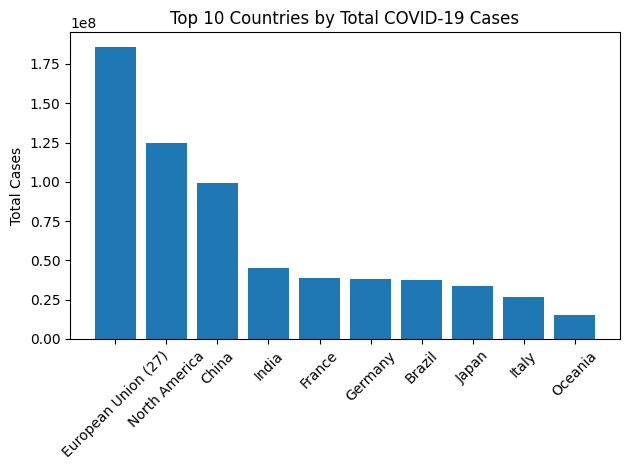

In [12]:
# Total Cases by top 10 countries
plt.bar(top10['location'], top10['total_cases'])
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Total COVID-19 Cases')
plt.ylabel('Total Cases')
plt.tight_layout()
plt.show()

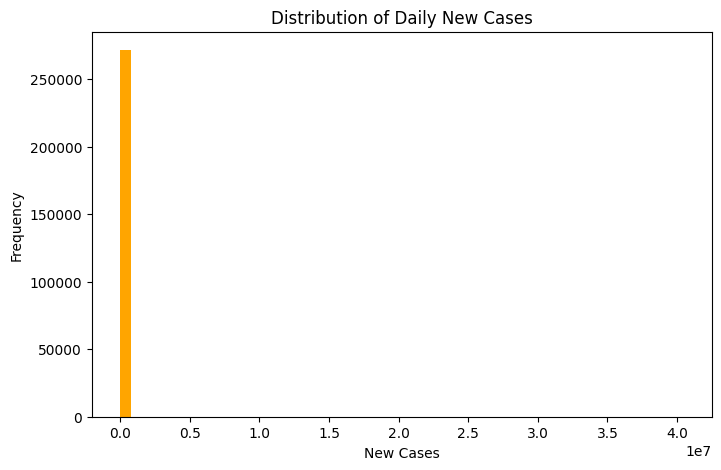

In [15]:
# Distribution of new cases
plt.figure(figsize=(8, 5))
plt.hist(df['new_cases'].dropna(), bins=50, color='orange')
plt.title('Distribution of Daily New Cases')
plt.xlabel('New Cases')
plt.ylabel('Frequency')
plt.show()

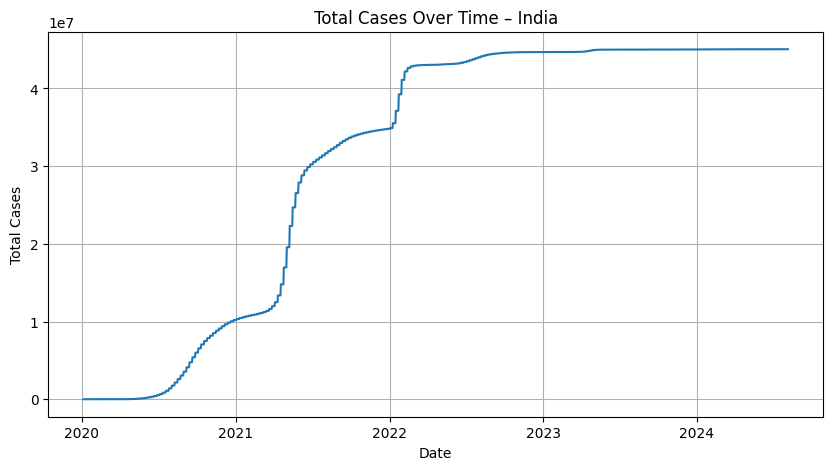

In [18]:
# Cases over time for a country
usa = df[df['location'] == 'India']
plt.figure(figsize=(10, 5))
plt.plot(usa['date'], usa['total_cases'])
plt.title('Total Cases Over Time – India')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.grid(True)
plt.show()

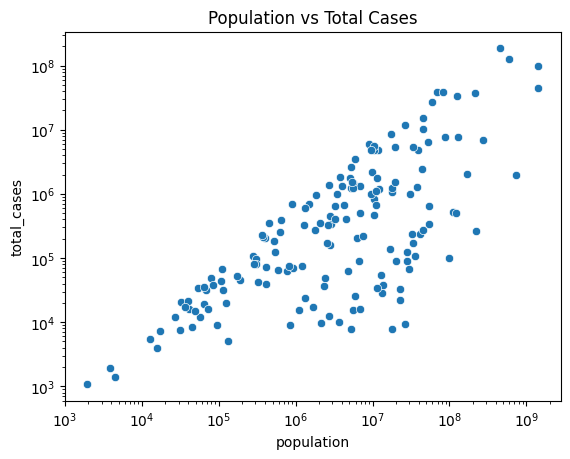

In [19]:
# Population vs Total Cases
sns.scatterplot(data=latest_df, x='population', y='total_cases')
plt.title('Population vs Total Cases')
plt.xscale('log')
plt.yscale('log')
plt.show()

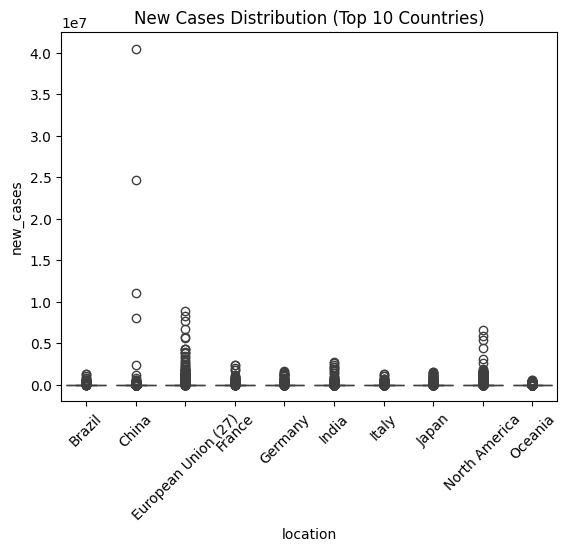

In [20]:
# Distribution off new cases in top 10 countries
top10_countries = top10['location'].tolist()
sns.boxplot(data=df[df['location'].isin(top10_countries)], x='location', y='new_cases')
plt.xticks(rotation=45)
plt.title('New Cases Distribution (Top 10 Countries)')
plt.show()

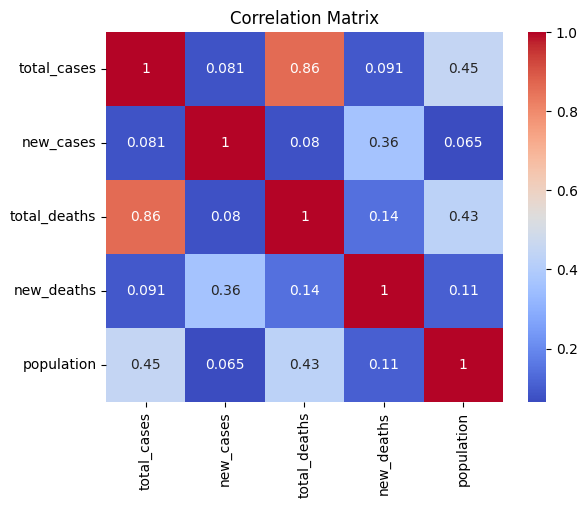

In [21]:
# Correlation matrix
corr = df[['total_cases', 'new_cases', 'total_deaths', 'new_deaths', 'population']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

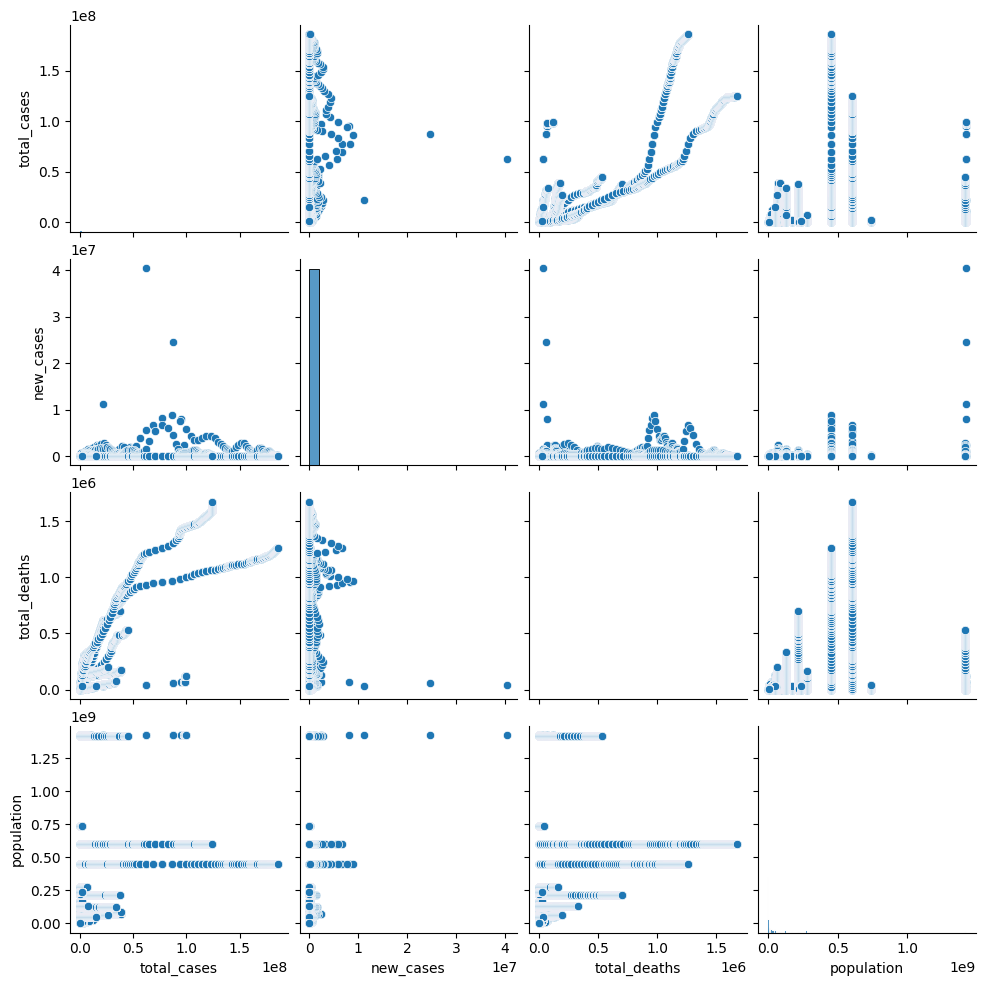

In [22]:
# Multivariate Visualization
sns.pairplot(df[['total_cases', 'new_cases', 'total_deaths', 'population']].dropna())
plt.show()

In [25]:
# Step 1: Get the latest date data
latest_df = df[df['date'] == df['date'].max()].copy()

# Step 2: Feature engineering
latest_df['cases_per_million'] = (latest_df['total_cases'] / latest_df['population']) * 1e6
latest_df['death_rate'] = (latest_df['total_deaths'] / latest_df['total_cases']) * 100


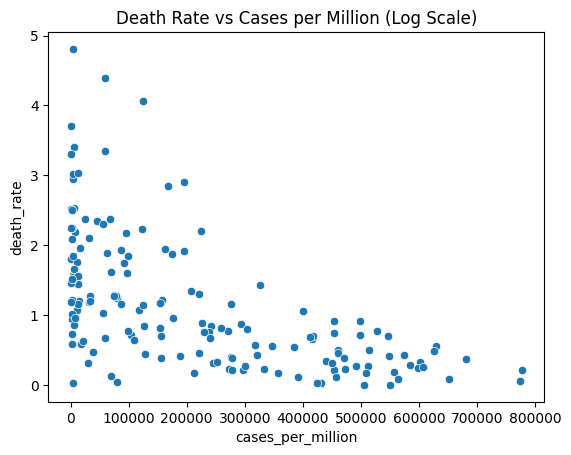

In [27]:
sns.scatterplot(data=latest_df, x='cases_per_million', y='death_rate')
plt.title('Death Rate vs Cases per Million (Log Scale)')
plt.show()